##### Week 2 – Model Building Progress Summary

✅ Train/test split — last 1 year as test data

✅ SARIMA model trained and evaluated

✅ Random Forest model trained and evaluated

✅ Model comparison

✅ Actual vs Random Forest prediction graph

✅ 30-day hourly forecast — 720 hours

✅ Forecast graph

✅ model_comparison.csv saved

✅ sarima_30_day_forecast.csv saved

# P705 - Forecasting Power Supply Demand

## Week 2 - Model Building

### Models
1. SARIMA
2. Random Forest

### Objective
To build and evaluate SARIMA and Random Forest models
for forecasting hourly power demand.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 1. Load the Cleaned Dataset
The cleaned power demand data prepared during the EDA phase
will be used for model building.

In [10]:
df = pd.read_csv("C:/Users/Admin/OneDrive/Documents/P705_Forecasting_Power_Supply_Demand/reports/PJMW_EDA_dataset.csv")

df.head()

,Datetime,PJMW_MW,Hour,Year,Month,Season,Day_Type,Holiday
0,2002-04-01 01:00:00,4374,1,2002,4,Spring,Weekday,Non-Holiday
1,2002-04-01 02:00:00,4306,2,2002,4,Spring,Weekday,Non-Holiday
2,2002-04-01 03:00:00,4322,3,2002,4,Spring,Weekday,Non-Holiday
3,2002-04-01 04:00:00,4359,4,2002,4,Spring,Weekday,Non-Holiday
4,2002-04-01 05:00:00,4436,5,2002,4,Spring,Weekday,Non-Holiday


## 2. Prepare the Datetime Column

Convert the Datetime column into datetime format,
sort the data by time, and set Datetime as the index.

In [14]:
# Convert Datetime column
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Sort data by Datetime
df = df.sort_values("Datetime").reset_index(drop=True)

# Set Datetime as index
df = df.set_index("Datetime")

# Display the first five rows
df.head()

,PJMW_MW,Hour,Year,Month,Season,Day_Type,Holiday
Datetime,,,,,,,
2002-04-01 01:00:00,4374,1,2002,4,Spring,Weekday,Non-Holiday
2002-04-01 02:00:00,4306,2,2002,4,Spring,Weekday,Non-Holiday
2002-04-01 03:00:00,4322,3,2002,4,Spring,Weekday,Non-Holiday
2002-04-01 04:00:00,4359,4,2002,4,Spring,Weekday,Non-Holiday
2002-04-01 05:00:00,4436,5,2002,4,Spring,Weekday,Non-Holiday


## 3. Check the Time Range

Check the first and last timestamps in the dataset
before creating the training and testing datasets.

In [17]:
# Check start and end dates
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

# Check total number of records
print("Total Records:", len(df))

Start Date: 2002-04-01 01:00:00
End Date: 2018-08-03 00:00:00
Total Records: 143206


## 4. Train-Test Split

The last one year of data will be used as the test set.
All earlier observations will be used for training.

In [20]:
# Define the last date in the dataset
last_date = df.index.max()

# Test period = last 1 year
test_start = last_date - pd.DateOffset(years=1)

# Split the data
train = df[df.index < test_start].copy()
test = df[df.index >= test_start].copy()

print("Training Data:")
print("Start:", train.index.min())
print("End:", train.index.max())
print("Records:", len(train))

print("\nTest Data:")
print("Start:", test.index.min())
print("End:", test.index.max())
print("Records:", len(test))

Training Data:
Start: 2002-04-01 01:00:00
End: 2017-08-02 23:00:00
Records: 134445

Test Data:
Start: 2017-08-03 00:00:00
End: 2018-08-03 00:00:00
Records: 8761


## 5. Prepare Data for SARIMA

SARIMA requires a time series with a regular time interval.
Duplicate timestamps are handled by taking their average demand.
The data is then converted to hourly frequency.

In [23]:
# Use power demand for SARIMA
sarima_df = df[["PJMW_MW"]].copy()

# Handle duplicate timestamps by taking the average demand
sarima_df = sarima_df.groupby(sarima_df.index).mean()

# Convert to regular hourly frequency
sarima_df = sarima_df.asfreq("h")

# Check missing values created by regular hourly frequency
print("Missing values:", sarima_df["PJMW_MW"].isna().sum())

# Fill any missing values using time interpolation
sarima_df["PJMW_MW"] = sarima_df["PJMW_MW"].interpolate(method="time")

print("Final records:", len(sarima_df))
sarima_df.head()

Missing values: 30
Final records: 143232


,PJMW_MW
Datetime,
2002-04-01 01:00:00,4374.0
2002-04-01 02:00:00,4306.0
2002-04-01 03:00:00,4322.0
2002-04-01 04:00:00,4359.0
2002-04-01 05:00:00,4436.0


## 6. SARIMA Train-Test Series

Create the training and testing time series using the
same one-year test period defined earlier.

In [25]:
# Create SARIMA train and test series
sarima_train = sarima_df[sarima_df.index < test_start]["PJMW_MW"]
sarima_test = sarima_df[sarima_df.index >= test_start]["PJMW_MW"]

print("SARIMA Training Records:", len(sarima_train))
print("SARIMA Test Records:", len(sarima_test))

print("\nTraining Period:")
print(sarima_train.index.min(), "to", sarima_train.index.max())

print("\nTest Period:")
print(sarima_test.index.min(), "to", sarima_test.index.max())

SARIMA Training Records: 134471
SARIMA Test Records: 8761

Training Period:
2002-04-01 01:00:00 to 2017-08-02 23:00:00

Test Period:
2017-08-03 00:00:00 to 2018-08-03 00:00:00


## 7. Check Daily Seasonality

Check whether power demand has a repeating daily pattern
using a 24-hour seasonal period.

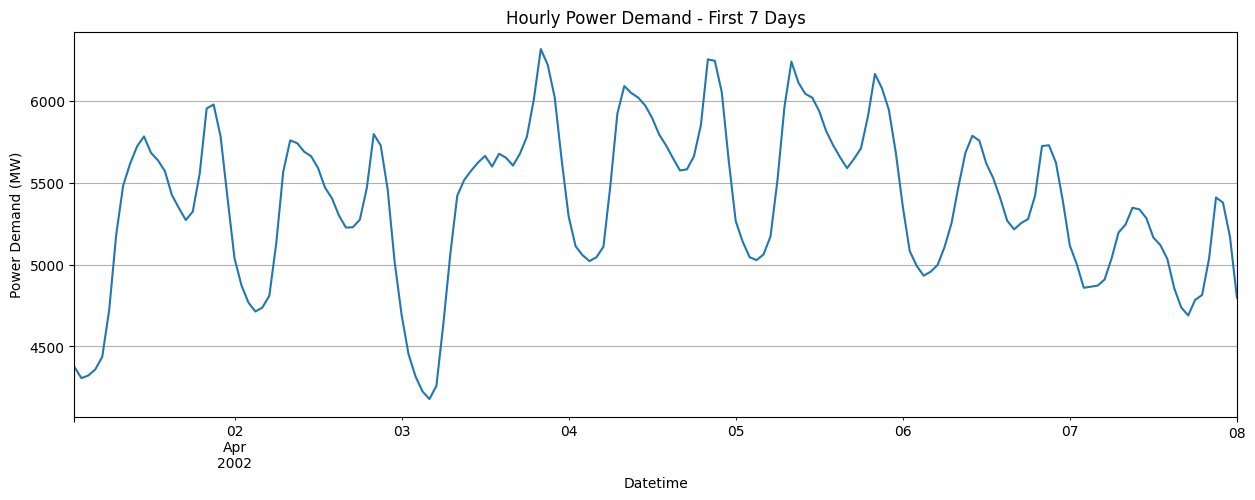

In [27]:
# Plot the first 7 days of training data
plt.figure(figsize=(15, 5))

sarima_train.iloc[:24 * 7].plot()

plt.title("Hourly Power Demand - First 7 Days")
plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.grid(True)
plt.show()

## 8. Stationarity Test - ADF

The Augmented Dickey-Fuller (ADF) test is used to check
whether the time series is stationary.

If the p-value is greater than 0.05, differencing may be required.

In [29]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
adf_result = adfuller(sarima_train.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Result: The series is stationary.")
else:
    print("Result: The series is not stationary. Differencing is required.")

ADF Statistic: -19.579533372778492
p-value: 0.0
Result: The series is stationary.


## 9. ACF and PACF Analysis

ACF is used to help identify the MA (q) parameter.

PACF is used to help identify the AR (p) parameter.

The seasonal period for the hourly data is 24 hours.

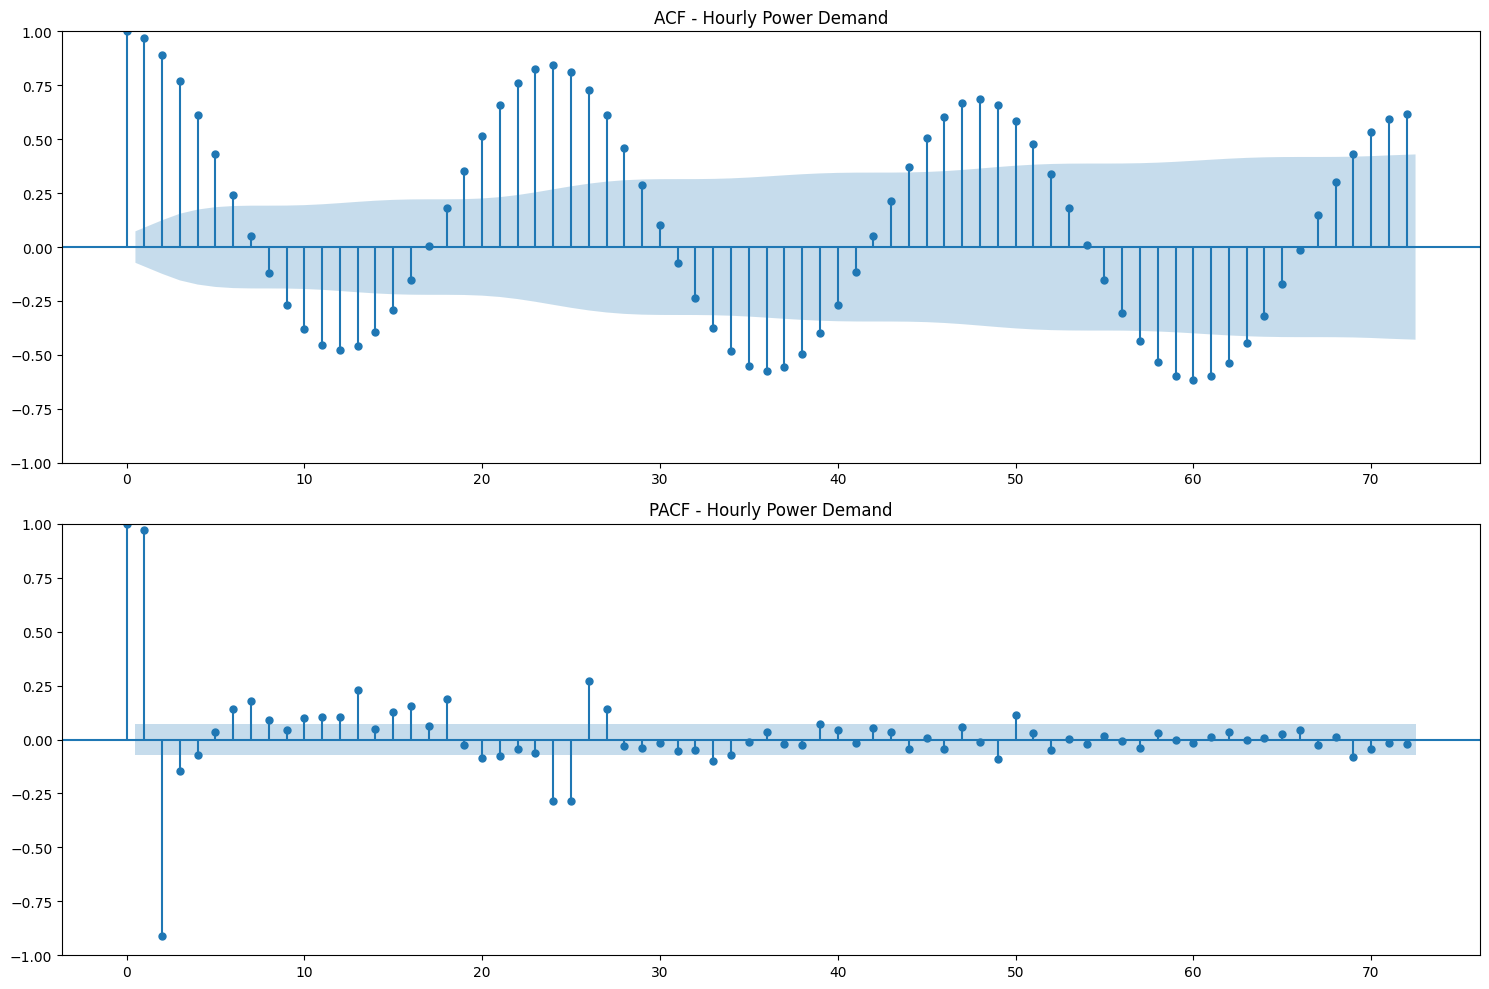

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use a smaller recent portion for ACF/PACF
acf_data = sarima_train.iloc[-24 * 30:]

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(acf_data, lags=72, ax=axes[0])
axes[0].set_title("ACF - Hourly Power Demand")

plot_pacf(acf_data, lags=72, ax=axes[1], method="ywm")
axes[1].set_title("PACF - Hourly Power Demand")

plt.tight_layout()
plt.show()

## 10. SARIMA Model Parameters

Based on the ADF, ACF and PACF analysis, the initial
SARIMA model parameters are:

- Non-seasonal order: (1, 0, 1)
- Seasonal order: (1, 0, 1, 24)

The seasonal period of 24 represents the daily pattern
in hourly power demand.

In [33]:
# SARIMA parameters

p = 1
d = 0
q = 1

P = 1
D = 0
Q = 1
seasonal_period = 24

order = (p, d, q)
seasonal_order = (P, D, Q, seasonal_period)

print("SARIMA order:", order)
print("Seasonal order:", seasonal_order)

SARIMA order: (1, 0, 1)
Seasonal order: (1, 0, 1, 24)


## 11. Train the SARIMA Model

Train the SARIMA model using the training dataset
and the selected model parameters.

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMA model
sarima_model = SARIMAX(
    sarima_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the model
sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            PJMW_MW   No. Observations:               134471
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -782001.129
Date:                            Thu, 24 Sep 2026   AIC                        1564012.258
Time:                                    14:28:47   BIC                        1564061.303
Sample:                                04-01-2002   HQIC                       1564026.947
                                     - 08-02-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9789      0.000   2202.348      0.000       0.978       0.980
ma.L1          0.3850      0.000   

## 12. SARIMA Test Prediction

Use the trained SARIMA model to predict power demand
for the complete one-year test period.

In [37]:
# Generate predictions for the test period
sarima_pred = sarima_result.get_forecast(
    steps=len(sarima_test)
)

# Extract predicted values
sarima_predictions = sarima_pred.predicted_mean

# Match the test index
sarima_predictions.index = sarima_test.index

# Display predictions
sarima_predictions.head()

Datetime
2017-08-03 00:00:00    5768.478463
2017-08-03 01:00:00    5400.708568
2017-08-03 02:00:00    5132.592947
2017-08-03 03:00:00    4958.237253
2017-08-03 04:00:00    4857.843146
Freq: h, Name: predicted_mean, dtype: float64

## 13. SARIMA Model Evaluation

Evaluate the SARIMA predictions using MAE, RMSE and MAPE.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
mae_sarima = mean_absolute_error(
    sarima_test,
    sarima_predictions
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        sarima_test,
        sarima_predictions
    )
)

mape_sarima = np.mean(
    np.abs(
        (sarima_test - sarima_predictions) / sarima_test
    )
) * 100

print("SARIMA Evaluation Results")
print("-------------------------")
print("MAE  :", mae_sarima)
print("RMSE :", rmse_sarima)
print("MAPE :", mape_sarima, "%")

SARIMA Evaluation Results
-------------------------
MAE  : 2096.070552133304
RMSE : 2469.086490468788
MAPE : 35.585344124229024 %


## 14. Actual vs SARIMA Predicted

Compare the actual power demand with the SARIMA predictions
for the test period.

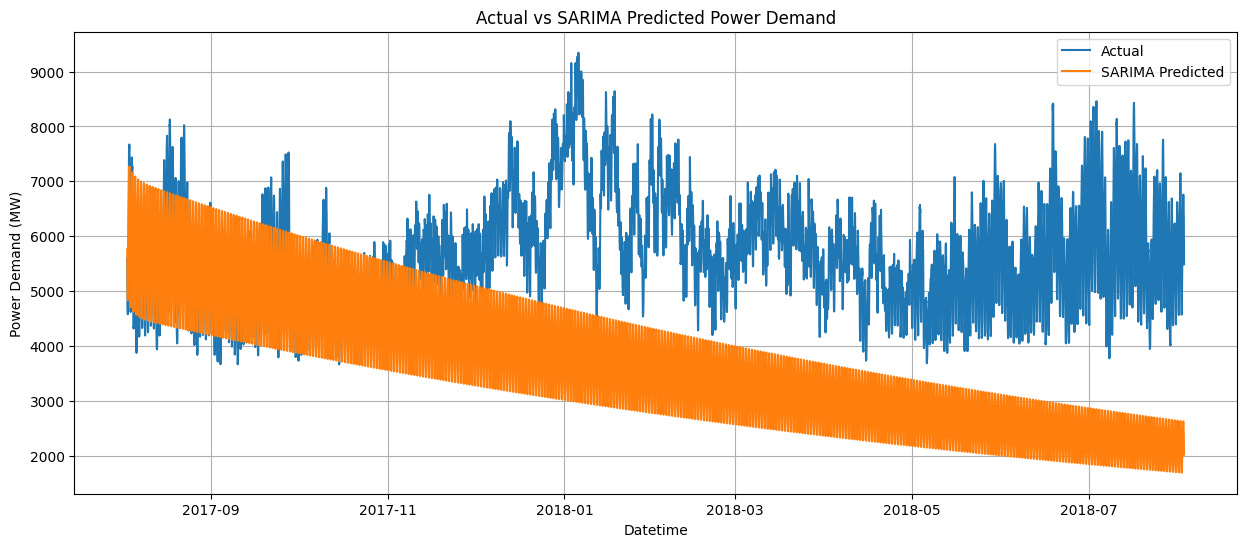

In [41]:
plt.figure(figsize=(15, 6))

plt.plot(
    sarima_test.index,
    sarima_test,
    label="Actual"
)

plt.plot(
    sarima_predictions.index,
    sarima_predictions,
    label="SARIMA Predicted"
)

plt.title("Actual vs SARIMA Predicted Power Demand")
plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

## 15. Prepare Features for Random Forest

Create time-based and lag features from the hourly power
demand data for Random Forest forecasting.

In [44]:
# Create a copy for Random Forest
rf_df = df[["PJMW_MW"]].copy()

# Time-based features
rf_df["Hour"] = rf_df.index.hour
rf_df["Day"] = rf_df.index.day
rf_df["Month"] = rf_df.index.month
rf_df["DayOfWeek"] = rf_df.index.dayofweek
rf_df["Year"] = rf_df.index.year

# Lag features
rf_df["Lag_1"] = rf_df["PJMW_MW"].shift(1)
rf_df["Lag_24"] = rf_df["PJMW_MW"].shift(24)
rf_df["Lag_168"] = rf_df["PJMW_MW"].shift(168)

# Remove rows with missing lag values
rf_df = rf_df.dropna()

rf_df.head()

,PJMW_MW,Hour,Day,Month,DayOfWeek,Year,Lag_1,Lag_24,Lag_168
Datetime,,,,,,,,,
2002-04-08 02:00:00,4532,2,8,4,0,2002,4634.0,5002.0,4374.0
2002-04-08 03:00:00,4481,3,8,4,0,2002,4532.0,4858.0,4306.0
2002-04-08 04:00:00,4527,4,8,4,0,2002,4481.0,4871.0,4322.0
2002-04-08 05:00:00,4640,5,8,4,0,2002,4527.0,4909.0,4359.0
2002-04-08 06:00:00,4940,6,8,4,0,2002,4640.0,5038.0,4436.0


## 16. Random Forest Train-Test Split

Use the same one-year test period used for SARIMA.
The remaining data will be used for training.

In [47]:
# Split Random Forest data
rf_train = rf_df[rf_df.index < test_start].copy()
rf_test = rf_df[rf_df.index >= test_start].copy()

print("Random Forest Training Records:", len(rf_train))
print("Random Forest Test Records:", len(rf_test))

print("\nTraining Period:")
print(rf_train.index.min(), "to", rf_train.index.max())

print("\nTest Period:")
print(rf_test.index.min(), "to", rf_test.index.max())

Random Forest Training Records: 134277
Random Forest Test Records: 8761

Training Period:
2002-04-08 02:00:00 to 2017-08-02 23:00:00

Test Period:
2017-08-03 00:00:00 to 2018-08-03 00:00:00


## 17. Create Features and Target

Separate the input features from the target variable
for Random Forest forecasting.

In [50]:
# Features used for Random Forest
features = [
    "Hour",
    "Day",
    "Month",
    "DayOfWeek",
    "Year",
    "Lag_1",
    "Lag_24",
    "Lag_168"
]

target = "PJMW_MW"

# Training features and target
X_train = rf_train[features]
y_train = rf_train[target]

# Testing features and target
X_test = rf_test[features]
y_test = rf_test[target]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (134277, 8)
y_train shape: (134277,)
X_test shape: (8761, 8)
y_test shape: (8761,)


## 18. Train the Random Forest Model

Train a Random Forest Regressor using the selected time-based
and lag features.

In [53]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model training completed.")

Random Forest model training completed.


## 19. Random Forest Test Prediction

Use the trained Random Forest model to predict power demand
for the complete one-year test period.

In [55]:
# Generate predictions
rf_predictions = rf_model.predict(X_test)

# Convert predictions to a Series with the test datetime index
rf_predictions = pd.Series(
    rf_predictions,
    index=y_test.index,
    name="RF_Predicted"
)

# Display first predictions
rf_predictions.head()

Datetime
2017-08-03 00:00:00    5761.07
2017-08-03 01:00:00    5202.20
2017-08-03 02:00:00    4873.31
2017-08-03 03:00:00    4751.33
2017-08-03 04:00:00    4596.01
Name: RF_Predicted, dtype: float64

## 20. Random Forest Model Evaluation

Evaluate the Random Forest predictions using MAE, RMSE and MAPE.

In [57]:
# Calculate evaluation metrics

mae_rf = mean_absolute_error(
    y_test,
    rf_predictions
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

mape_rf = np.mean(
    np.abs(
        (y_test - rf_predictions) / y_test
    )
) * 100

print("Random Forest Evaluation Results")
print("--------------------------------")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)
print("MAPE :", mape_rf, "%")

Random Forest Evaluation Results
--------------------------------
MAE  : 60.53402465471978
RMSE : 79.90162251884317
MAPE : 1.0577519339844026 %


## 21. Model Comparison

Compare the performance of SARIMA and Random Forest
using MAE, RMSE and MAPE.

In [65]:
# Create model comparison table

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Random Forest"],
    "MAE": [mae_sarima, mae_rf],
    "RMSE": [rmse_sarima, rmse_rf],
    "MAPE (%)": [mape_sarima, mape_rf]
})

comparison

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,2096.070552,2469.086490,35.585344
1,Random Forest,60.534025,79.901623,1.057752


## 22. Actual vs Random Forest Predicted

Compare the actual power demand with the predictions
generated by the Random Forest model.

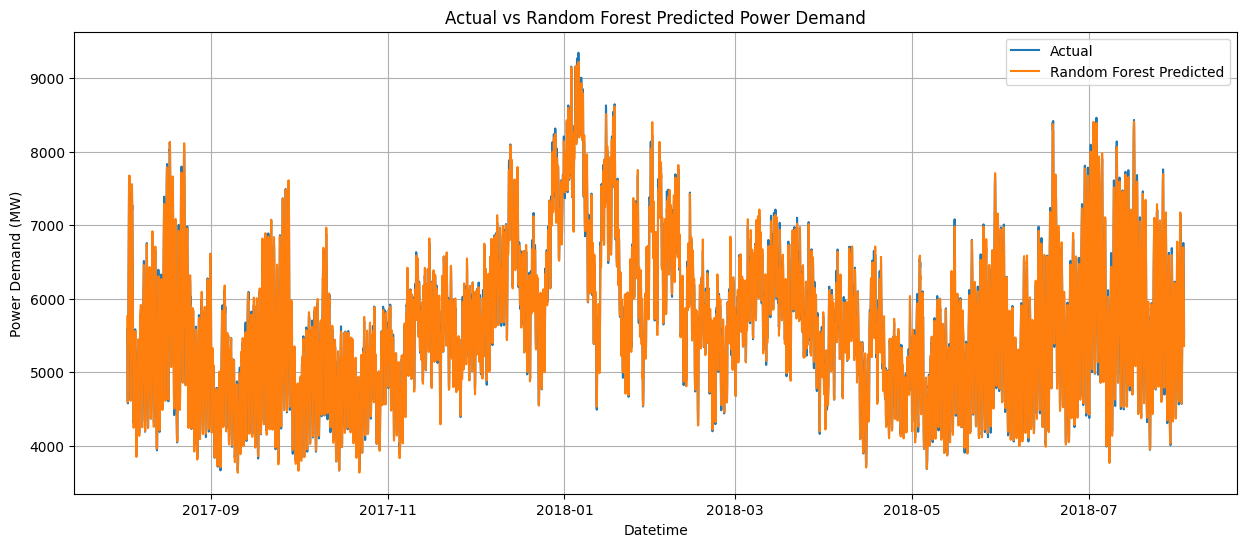

In [67]:
plt.figure(figsize=(15, 6))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(rf_predictions.index, rf_predictions, label="Random Forest Predicted")

plt.title("Actual vs Random Forest Predicted Power Demand")
plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [69]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="`sklearn.utils.parallel.delayed` should be used"
)

## 23. Forecast Next 30 Days Using SARIMA

Generate an hourly power demand forecast for the next 30 days
using the trained SARIMA model.

In [72]:
forecast_hours = 30 * 24

sarima_30day = sarima_result.get_forecast(
    steps=forecast_hours
)

sarima_30day_predictions = sarima_30day.predicted_mean

future_index = pd.date_range(
    start=sarima_df.index.max() + pd.Timedelta(hours=1),
    periods=forecast_hours,
    freq="h"
)

sarima_30day_forecast = pd.DataFrame({
    "Datetime": future_index,
    "Forecast_MW": sarima_30day_predictions.values
}).set_index("Datetime")

print("30-Day Forecast Generated")
print("Start:", sarima_30day_forecast.index.min())
print("End:", sarima_30day_forecast.index.max())
print("Total Forecast Hours:", len(sarima_30day_forecast))

sarima_30day_forecast.head(10)

30-Day Forecast Generated
Start: 2018-08-03 01:00:00
End: 2018-09-02 00:00:00
Total Forecast Hours: 720


,Forecast_MW
Datetime,
2018-08-03 01:00:00,5768.478463
2018-08-03 02:00:00,5400.708568
2018-08-03 03:00:00,5132.592947
2018-08-03 04:00:00,4958.237253
2018-08-03 05:00:00,4857.843146
2018-08-03 06:00:00,4837.447353
2018-08-03 07:00:00,4958.340836
2018-08-03 08:00:00,5137.421887
2018-08-03 09:00:00,5376.768071


## 24. 30-Day Power Demand Forecast

Visualize the forecasted hourly power demand for the next 30 days.

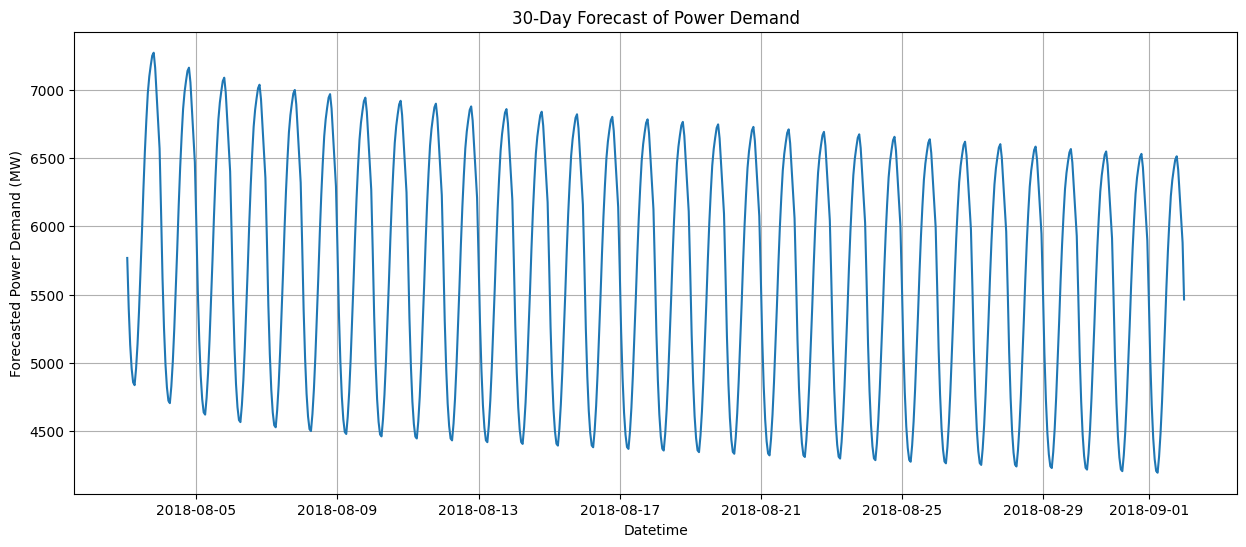

In [75]:
plt.figure(figsize=(15, 6))

plt.plot(
    sarima_30day_forecast.index,
    sarima_30day_forecast["Forecast_MW"]
)

plt.title("30-Day Forecast of Power Demand")
plt.xlabel("Datetime")
plt.ylabel("Forecasted Power Demand (MW)")
plt.grid(True)
plt.show()

## 25. Save Model Results

Save the model comparison and 30-day forecast results
for documentation and final presentation.

In [78]:
comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

sarima_30day_forecast.to_csv(
    "../reports/sarima_30_day_forecast.csv"
)

print("Model comparison saved successfully.")
print("30-day forecast saved successfully.")

Model comparison saved successfully.
30-day forecast saved successfully.


# Alternative Train-Test Split Analysis

## Random Forest - Full Year 2017 Test Set

Training Period: 2002–2016  
Testing Period: 2017

This alternative split is created separately for comparison
with the original train-test split.

In [81]:
rf_alt_train = rf_df[rf_df.index < "2017-01-01"].copy()

rf_alt_test = rf_df[
    (rf_df.index >= "2017-01-01") &
    (rf_df.index < "2018-01-01")
].copy()

print("Alternative Random Forest Split")
print("--------------------------------")
print("Training Start:", rf_alt_train.index.min())
print("Training End:", rf_alt_train.index.max())
print("Training Records:", len(rf_alt_train))

print("\nTesting Start:", rf_alt_test.index.min())
print("Testing End:", rf_alt_test.index.max())
print("Testing Records:", len(rf_alt_test))

Alternative Random Forest Split
--------------------------------
Training Start: 2002-04-08 02:00:00
Training End: 2016-12-31 23:00:00
Training Records: 129142

Testing Start: 2017-01-01 00:00:00
Testing End: 2017-12-31 23:00:00
Testing Records: 8760


## Prepare Features and Target

The same features used in the original Random Forest model
are used for the alternative split.

In [84]:
X_alt_train = rf_alt_train[features]
y_alt_train = rf_alt_train[target]

X_alt_test = rf_alt_test[features]
y_alt_test = rf_alt_test[target]

print("X_train shape:", X_alt_train.shape)
print("y_train shape:", y_alt_train.shape)
print("X_test shape:", X_alt_test.shape)
print("y_test shape:", y_alt_test.shape)

X_train shape: (129142, 8)
y_train shape: (129142,)
X_test shape: (8760, 8)
y_test shape: (8760,)


## Train Random Forest Model - Alternative Split

A new Random Forest model is trained using data from 2002 to 2016.

In [87]:
rf_alt_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_alt_model.fit(X_alt_train, y_alt_train)

print("Alternative Random Forest training completed.")

Alternative Random Forest training completed.


## Predict Power Demand for 2017

The trained Random Forest model is used to predict hourly
power demand for the complete 2017 test period.

In [90]:
rf_alt_predictions = rf_alt_model.predict(X_alt_test)

rf_alt_predictions = pd.Series(
    rf_alt_predictions,
    index=y_alt_test.index,
    name="RF_Alternative_Predicted"
)

rf_alt_predictions.head()

Datetime
2017-01-01 00:00:00    5161.53
2017-01-01 01:00:00    4936.17
2017-01-01 02:00:00    4902.13
2017-01-01 03:00:00    4852.26
2017-01-01 04:00:00    4788.42
Name: RF_Alternative_Predicted, dtype: float64

## Evaluate Alternative Random Forest Model

The alternative model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

In [93]:
mae_rf_alt = mean_absolute_error(
    y_alt_test,
    rf_alt_predictions
)

rmse_rf_alt = np.sqrt(
    mean_squared_error(
        y_alt_test,
        rf_alt_predictions
    )
)

mape_rf_alt = np.mean(
    np.abs(
        (y_alt_test - rf_alt_predictions) / y_alt_test
    )
) * 100

print("Alternative Random Forest Results")
print("----------------------------------")
print("MAE  :", mae_rf_alt)
print("RMSE :", rmse_rf_alt)
print("MAPE :", mape_rf_alt, "%")

Alternative Random Forest Results
----------------------------------
MAE  : 57.94572602739726
RMSE : 76.77900480284947
MAPE : 1.0512582579600047 %


## Actual vs Alternative Random Forest Predictions

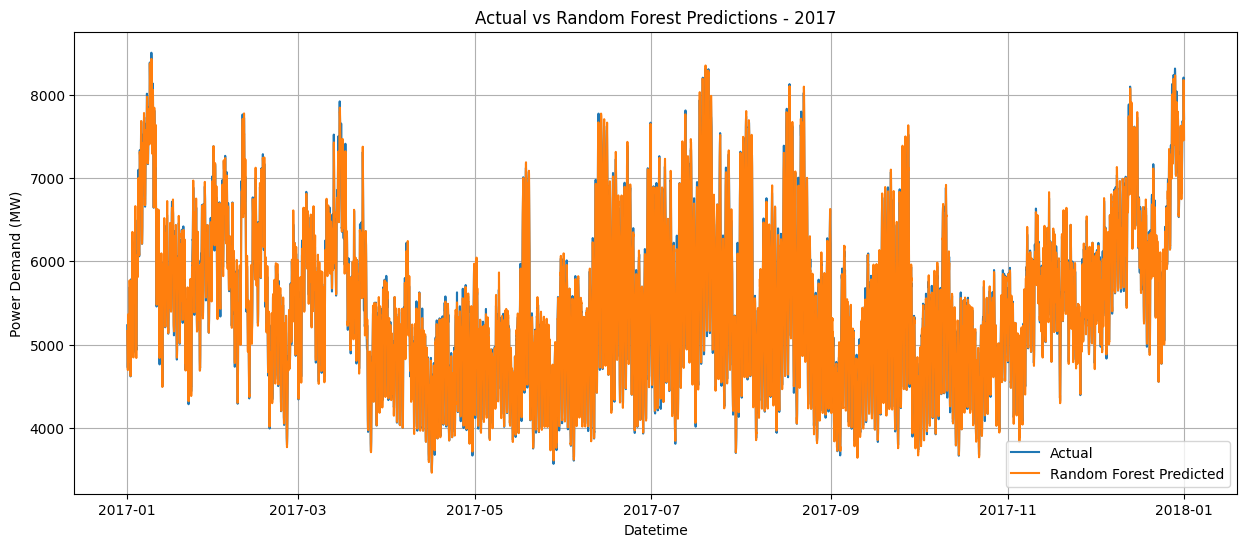

In [96]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_alt_test.index,
    y_alt_test,
    label="Actual"
)

plt.plot(
    rf_alt_predictions.index,
    rf_alt_predictions,
    label="Random Forest Predicted"
)

plt.title("Actual vs Random Forest Predictions - 2017")
plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

## Comparison of Random Forest Train-Test Splits

The Random Forest model was evaluated using two different
train-test split strategies.

### Original Split
- Training: 2002 to 2017
- Testing: Last one year of available data

### Alternative Split
- Training: 2002 to 2016
- Testing: Full year 2017

The evaluation metrics are compared using MAE, RMSE and MAPE.

In [99]:
rf_split_comparison = pd.DataFrame({
    "Split": [
        "Original Split",
        "Alternative Split (2002-2016 Train, 2017 Test)"
    ],
    "MAE": [
        mae_rf,
        mae_rf_alt
    ],
    "RMSE": [
        rmse_rf,
        rmse_rf_alt
    ],
    "MAPE (%)": [
        mape_rf,
        mape_rf_alt
    ]
})

rf_split_comparison

,Split,MAE,RMSE,MAPE (%)
0,Original Split,60.534025,79.901623,1.057752
1,"Alternative Split (2002-2016 Train, 2017 Test)",57.945726,76.779005,1.051258


## Random Forest Split Analysis

The alternative split produced slightly lower MAE, RMSE and MAPE
than the original split.

This comparison helps evaluate whether using a complete calendar
year as the test period provides a different assessment of model
performance.

The final split will be selected after considering the model
performance and the project requirements.

# SARIMA Fine-Tuning and Critical Analysis

## Objective

To investigate whether changing the SARIMA parameters can improve
the performance of the baseline SARIMA model.

The baseline model is:

- Order: (1, 0, 1)
- Seasonal Order: (1, 0, 1, 24)

Candidate models are selected using the ACF/PACF analysis.

Each model will be evaluated using MAE, RMSE and MAPE.

## SARIMA Candidate Parameter Combinations

The following combinations are selected by varying the
non-seasonal AR and MA terms and the seasonal AR and MA terms.

The differencing terms remain unchanged because the ADF test
indicated that the series is stationary.

In [104]:
sarima_candidates = [
    ((1, 0, 1), (1, 0, 1, 24)),  # Baseline
    ((2, 0, 1), (1, 0, 1, 24)),
    ((1, 0, 2), (1, 0, 1, 24)),
    ((2, 0, 2), (1, 0, 1, 24)),
    ((1, 0, 1), (2, 0, 1, 24)),
    ((1, 0, 1), (1, 0, 2, 24)),
    ((2, 0, 1), (2, 0, 1, 24)),
    ((1, 0, 2), (1, 0, 2, 24))
]

print("Number of candidate models:", len(sarima_candidates))

for i, (order, seasonal_order) in enumerate(sarima_candidates, 1):
    print(
        f"{i}. Order={order}, "
        f"Seasonal Order={seasonal_order}"
    )

Number of candidate models: 8
1. Order=(1, 0, 1), Seasonal Order=(1, 0, 1, 24)
2. Order=(2, 0, 1), Seasonal Order=(1, 0, 1, 24)
3. Order=(1, 0, 2), Seasonal Order=(1, 0, 1, 24)
4. Order=(2, 0, 2), Seasonal Order=(1, 0, 1, 24)
5. Order=(1, 0, 1), Seasonal Order=(2, 0, 1, 24)
6. Order=(1, 0, 1), Seasonal Order=(1, 0, 2, 24)
7. Order=(2, 0, 1), Seasonal Order=(2, 0, 1, 24)
8. Order=(1, 0, 2), Seasonal Order=(1, 0, 2, 24)


## Train and Evaluate SARIMA Candidate Models

Each candidate SARIMA configuration is fitted on the same training
data and evaluated on the same test data.

The evaluation metrics are:
- MAE
- RMSE
- MAPE

In [107]:
sarima_tuning_results = []

for i, (order, seasonal_order) in enumerate(sarima_candidates, 1):

    print(f"\nTraining Model {i}/8")
    print("Order:", order)
    print("Seasonal Order:", seasonal_order)

    model = SARIMAX(
        sarima_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    predictions = result.get_forecast(
        steps=len(sarima_test)
    ).predicted_mean

    predictions.index = sarima_test.index

    mae = mean_absolute_error(
        sarima_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            sarima_test,
            predictions
        )
    )

    mape = np.mean(
        np.abs(
            (sarima_test - predictions) / sarima_test
        )
    ) * 100

    sarima_tuning_results.append({
        "Model": i,
        "Order": order,
        "Seasonal_Order": seasonal_order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape, "%")

sarima_tuning_results = pd.DataFrame(
    sarima_tuning_results
)

print("\nSARIMA Fine-Tuning Completed.")


Training Model 1/8
Order: (1, 0, 1)
Seasonal Order: (1, 0, 1, 24)


MemoryError: Unable to allocate 694. MiB for an array with shape (26, 26, 134471) and data type float64

## SARIMA Fine-Tuning Using a Reduced Training Window

The full SARIMA training dataset is large and causes high memory
usage during repeated parameter tuning.

Therefore, a reduced recent training window is used for parameter
search. This allows different SARIMA configurations to be tested
without exceeding available system memory.

The original full-data SARIMA model and its results are retained
as the baseline.

In [110]:
# Use the last 2 years of the training data for fine-tuning

tuning_hours = 2 * 365 * 24

sarima_tune_train = sarima_train.iloc[-tuning_hours:]

print("Fine-Tuning Training Data")
print("-------------------------")
print("Start:", sarima_tune_train.index.min())
print("End:", sarima_tune_train.index.max())
print("Records:", len(sarima_tune_train))

Fine-Tuning Training Data
-------------------------
Start: 2015-08-04 00:00:00
End: 2017-08-02 23:00:00
Records: 17520


## SARIMA Fine-Tuning - Memory Efficient Search

A smaller set of candidate models will be tested using the
reduced training window.

The purpose is to identify whether alternative AR, MA,
seasonal AR and seasonal MA terms can improve the baseline.

In [113]:
sarima_tuning_candidates = [
    ((1, 0, 1), (1, 0, 1, 24)),  # Baseline
    ((2, 0, 1), (1, 0, 1, 24)),
    ((1, 0, 2), (1, 0, 1, 24)),
    ((2, 0, 2), (1, 0, 1, 24))
]

for i, (order, seasonal_order) in enumerate(
    sarima_tuning_candidates, 1
):
    print(
        f"{i}. Order={order}, "
        f"Seasonal Order={seasonal_order}"
    )

1. Order=(1, 0, 1), Seasonal Order=(1, 0, 1, 24)
2. Order=(2, 0, 1), Seasonal Order=(1, 0, 1, 24)
3. Order=(1, 0, 2), Seasonal Order=(1, 0, 1, 24)
4. Order=(2, 0, 2), Seasonal Order=(1, 0, 1, 24)


## Train and Evaluate SARIMA Fine-Tuning Models

The candidate SARIMA models are trained using the reduced
two-year training window.

The models are compared using MAE, RMSE and MAPE.

In [116]:
sarima_tuning_results = []

for i, (order, seasonal_order) in enumerate(
    sarima_tuning_candidates, 1
):

    print(f"\nTraining Model {i}/4")
    print("Order:", order)
    print("Seasonal Order:", seasonal_order)

    model = SARIMAX(
        sarima_tune_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        low_memory=True
    )

    predictions = result.get_forecast(
        steps=len(sarima_test)
    ).predicted_mean

    predictions.index = sarima_test.index

    mae = mean_absolute_error(
        sarima_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            sarima_test,
            predictions
        )
    )

    mape = np.mean(
        np.abs(
            (sarima_test - predictions) / sarima_test
        )
    ) * 100

    sarima_tuning_results.append({
        "Model": i,
        "Order": order,
        "Seasonal_Order": seasonal_order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape, "%")

sarima_tuning_results = pd.DataFrame(
    sarima_tuning_results
)

print("\nSARIMA Fine-Tuning Completed.")


Training Model 1/4
Order: (1, 0, 1)
Seasonal Order: (1, 0, 1, 24)


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 2462.3683382935824
RMSE: 2870.7577422502272
MAPE: 41.94780324209168 %

Training Model 2/4
Order: (2, 0, 1)
Seasonal Order: (1, 0, 1, 24)


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 2688.212163024912
RMSE: 3101.7714282563566
MAPE: 45.882687296212445 %

Training Model 3/4
Order: (1, 0, 2)
Seasonal Order: (1, 0, 1, 24)


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 2599.2309226901853
RMSE: 3013.0686287594904
MAPE: 44.329095482338694 %

Training Model 4/4
Order: (2, 0, 2)
Seasonal Order: (1, 0, 1, 24)


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 1957.6833890815249
RMSE: 2313.964237293533
MAPE: 33.164354088070716 %

SARIMA Fine-Tuning Completed.


## SARIMA Fine-Tuning Results

The fine-tuning experiment tested four SARIMA configurations
using the reduced two-year training window.

Among the tested configurations, SARIMA(2,0,2)(1,0,1,24)
produced the lowest MAE, RMSE and MAPE in this experiment.

This configuration will be further validated before selecting
the final SARIMA model.

In [119]:
sarima_tuning_results

,Model,Order,Seasonal_Order,MAE,RMSE,MAPE (%)
0,1,"(1, 0, 1)","(1, 0, 1, 24)",2462.368338,2870.757742,41.947803
1,2,"(2, 0, 1)","(1, 0, 1, 24)",2688.212163,3101.771428,45.882687
2,3,"(1, 0, 2)","(1, 0, 1, 24)",2599.230923,3013.068629,44.329095
3,4,"(2, 0, 2)","(1, 0, 1, 24)",1957.683389,2313.964237,33.164354


## Validation of Best SARIMA Configuration

The SARIMA(2,0,2)(1,0,1,24) configuration showed the lowest
error among the tested configurations.

This configuration is now validated using a validation period
from the reduced training dataset before final model selection.

In [122]:
# Create an inner validation split
validation_hours = 30 * 24

sarima_inner_train = sarima_tune_train.iloc[:-validation_hours]
sarima_validation = sarima_tune_train.iloc[-validation_hours:]

print("Inner Training Period:")
print(sarima_inner_train.index.min(), "to", sarima_inner_train.index.max())

print("\nValidation Period:")
print(sarima_validation.index.min(), "to", sarima_validation.index.max())

print("\nValidation Records:", len(sarima_validation))

Inner Training Period:
2015-08-04 00:00:00 to 2017-07-03 23:00:00

Validation Period:
2017-07-04 00:00:00 to 2017-08-02 23:00:00

Validation Records: 720


## Validate SARIMA(2,0,2)(1,0,1,24)

The selected SARIMA configuration is trained on the inner
training dataset and evaluated on the 30-day validation period.

In [125]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

validation_model = SARIMAX(
    sarima_inner_train,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

validation_result = validation_model.fit(
    disp=False,
    low_memory=True
)

validation_predictions = validation_result.get_forecast(
    steps=len(sarima_validation)
).predicted_mean

validation_predictions.index = sarima_validation.index

validation_mae = mean_absolute_error(
    sarima_validation,
    validation_predictions
)

validation_rmse = np.sqrt(
    mean_squared_error(
        sarima_validation,
        validation_predictions
    )
)

validation_mape = np.mean(
    np.abs(
        (sarima_validation - validation_predictions)
        / sarima_validation
    )
) * 100

print("Validation Results")
print("------------------")
print("MAE :", validation_mae)
print("RMSE:", validation_rmse)
print("MAPE:", validation_mape, "%")

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Validation Results
------------------
MAE : 1285.527839353704
RMSE: 1514.2077847650664
MAPE: 21.350650561578416 %


## SARIMA Fine-Tuning - Seasonal Parameter Analysis

The previous experiments varied the non-seasonal AR and MA
parameters while keeping the daily seasonal period at 24 hours.

Additional configurations are tested by varying the seasonal
AR and MA terms to examine whether the daily seasonality can
be captured more effectively.

In [128]:
seasonal_candidates = [
    ((1, 0, 1), (1, 0, 1, 24)),
    ((1, 0, 1), (2, 0, 1, 24)),
    ((1, 0, 1), (1, 0, 2, 24)),
    ((2, 0, 2), (2, 0, 1, 24)),
    ((2, 0, 2), (1, 0, 2, 24))
]

for i, (order, seasonal_order) in enumerate(
    seasonal_candidates, 1
):
    print(
        f"{i}. Order={order}, "
        f"Seasonal Order={seasonal_order}"
    )

1. Order=(1, 0, 1), Seasonal Order=(1, 0, 1, 24)
2. Order=(1, 0, 1), Seasonal Order=(2, 0, 1, 24)
3. Order=(1, 0, 1), Seasonal Order=(1, 0, 2, 24)
4. Order=(2, 0, 2), Seasonal Order=(2, 0, 1, 24)
5. Order=(2, 0, 2), Seasonal Order=(1, 0, 2, 24)


## Seasonal SARIMA Validation

The candidate models are evaluated on the same 30-day
validation period.

MAE, RMSE and MAPE are used to compare the configurations.

In [131]:
seasonal_validation_results = []

for i, (order, seasonal_order) in enumerate(
    seasonal_candidates, 1
):

    print(f"\nTraining Seasonal Model {i}/5")
    print("Order:", order)
    print("Seasonal Order:", seasonal_order)

    model = SARIMAX(
        sarima_inner_train,
        order=order,
        seasonal_order=seasonal_order,        
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        low_memory=True
    )

    predictions = result.get_forecast(
        steps=len(sarima_validation)
    ).predicted_mean

    predictions.index = sarima_validation.index

    mae = mean_absolute_error(
        sarima_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            sarima_validation,
            predictions
        )
    )

    mape = np.mean(
        np.abs(
            (sarima_validation - predictions)
            / sarima_validation
        )
    ) * 100

    seasonal_validation_results.append({
        "Model": i,
        "Order": order,
        "Seasonal_Order": seasonal_order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape, "%")

seasonal_validation_results = pd.DataFrame(
    seasonal_validation_results
)

print("\nSeasonal Validation Completed.")


Training Seasonal Model 1/5
Order: (1, 0, 1)
Seasonal Order: (1, 0, 1, 24)


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 463.4967935617617
RMSE: 592.0489287319971
MAPE: 7.883622903826554 %

Training Seasonal Model 2/5
Order: (1, 0, 1)
Seasonal Order: (2, 0, 1, 24)


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 3894.819083770685
RMSE: 4441.172521093635
MAPE: 65.21572140474225 %

Training Seasonal Model 3/5
Order: (1, 0, 1)
Seasonal Order: (1, 0, 2, 24)


...

MAE : 596.1934678941535
RMSE: 742.9146985071353
MAPE: 9.758130740521432 %

Training Seasonal Model 4/5
Order: (2, 0, 2)
Seasonal Order: (2, 0, 1, 24)


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 1097.4425402719473
RMSE: 1310.5377214297032
MAPE: 18.163513666020798 %

Training Seasonal Model 5/5
Order: (2, 0, 2)
Seasonal Order: (1, 0, 2, 24)


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 1039.9563731992264
RMSE: 1245.170539929704
MAPE: 17.00464871573438 %

Seasonal Validation Completed.


## Final SARIMA Model

Based on the validation results, SARIMA(1,0,1)(1,0,1,24)
is selected for final evaluation.

The model is refitted using the complete training dataset
and evaluated on the original one-year test period.

In [136]:
final_sarima_model = SARIMAX(
    sarima_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_result = final_sarima_model.fit(
    disp=False,
    low_memory=True
)

final_sarima_predictions = final_sarima_result.get_forecast(
    steps=len(sarima_test)
).predicted_mean

final_sarima_predictions.index = sarima_test.index

final_mae = mean_absolute_error(
    sarima_test,
    final_sarima_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        sarima_test,
        final_sarima_predictions
    )
)

final_mape = np.mean(
    np.abs(
        (sarima_test - final_sarima_predictions)
        / sarima_test
    )
) * 100

print("Final SARIMA Results")
print("--------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("MAPE:", final_mape, "%")

Final SARIMA Results
--------------------
MAE : 2096.070552133304
RMSE: 2469.086490468788
MAPE: 35.585344124229024 %


#####
“SARIMA was able to capture the daily 24-hour seasonal pattern, but its performance on the full one-year forecasting horizon was limited, with a MAPE of 35.59%. Fine-tuning showed that changing AR, MA and seasonal parameters produced substantially different results across validation periods. This indicates that the model's performance is sensitive to parameter configuration and forecasting horizon. The final SARIMA model was therefore retained as a benchmark model.”

## Random Forest Model Evaluation

The Random Forest model is evaluated using the same forecasting
target, with MAE, RMSE and MAPE used as performance metrics.

The original test period is retained for the final evaluation.

In [140]:
# Final Random Forest predictions on the original test period

rf_final_predictions = rf_model.predict(X_test)

rf_final_mae = mean_absolute_error(
    y_test,
    rf_final_predictions
)

rf_final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_final_predictions
    )
)

rf_final_mape = np.mean(
    np.abs(
        (y_test - rf_final_predictions) / y_test
    )
) * 100

print("Final Random Forest Results")
print("---------------------------")
print("MAE :", rf_final_mae)
print("RMSE:", rf_final_rmse)
print("MAPE:", rf_final_mape, "%")

Final Random Forest Results
---------------------------
MAE : 60.53402465471978
RMSE: 79.90162251884317
MAPE: 1.0577519339844026 %


## Final Model Comparison

The final SARIMA and Random Forest models are compared using
MAE, RMSE and MAPE on their respective test evaluations.

Lower values indicate lower forecasting error.

In [143]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Random Forest"
    ],
    "MAE": [
        final_mae,
        rf_final_mae
    ],
    "RMSE": [
        final_rmse,
        rf_final_rmse
    ],
    "MAPE (%)": [
        final_mape,
        rf_final_mape
    ]
})

final_model_comparison

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,2096.070552,2469.086490,35.585344
1,Random Forest,60.534025,79.901623,1.057752


## Final Model Performance Comparison

The performance of SARIMA and Random Forest is compared using
MAE, RMSE and MAPE.

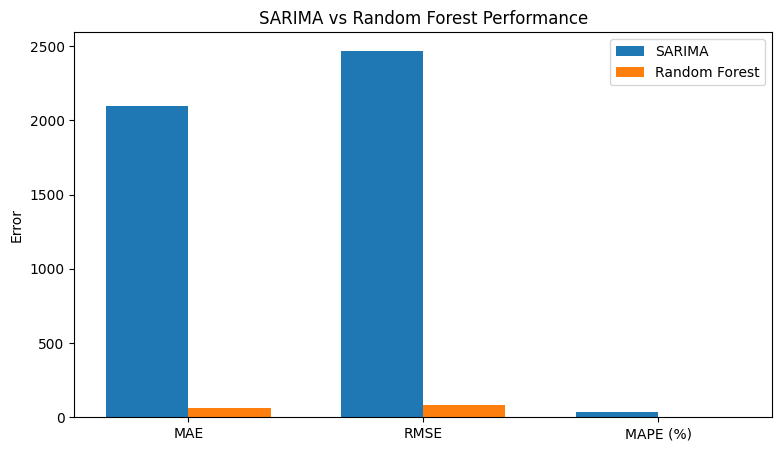

In [146]:
# Plot final model comparison

metrics = ["MAE", "RMSE", "MAPE (%)"]

sarima_values = [
    final_mae,
    final_rmse,
    final_mape
]

rf_values = [
    rf_final_mae,
    rf_final_rmse,
    rf_final_mape
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    sarima_values,
    width,
    label="SARIMA"
)

plt.bar(
    x + width/2,
    rf_values,
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Error")
plt.title("SARIMA vs Random Forest Performance")
plt.legend()

plt.show()

## Final Model Critical Analysis

SARIMA captured the daily 24-hour seasonal pattern, but its
one-year test performance was limited, with a MAPE of 35.59%.

SARIMA fine-tuning showed that changing AR, MA and seasonal
parameters did not consistently improve performance. The
baseline configuration achieved the lowest error on the
30-day validation period.

Random Forest achieved MAE of 60.53 MW, RMSE of 79.90 MW and
MAPE of 1.06% under the current test evaluation.

However, the two models were evaluated differently. Random
Forest used observed lag values for each test timestamp,
whereas SARIMA generated a long-horizon forecast from the end
of the training period. Therefore, the metrics should be
interpreted within the current evaluation setup.

SARIMA is retained as a classical time-series benchmark, while
Random Forest showed lower observed test errors under the
current evaluation setup.

## Random Forest Feature Importance

Feature importance is used to understand which input features
contributed most to the Random Forest model's predictions.

In [150]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
5,Lag_1,0.950323
0,Hour,0.037985
2,Month,0.005344
6,Lag_24,0.001634
3,DayOfWeek,0.001550
7,Lag_168,0.001231
1,Day,0.000966
4,Year,0.000965


### Feature Importance Visualization

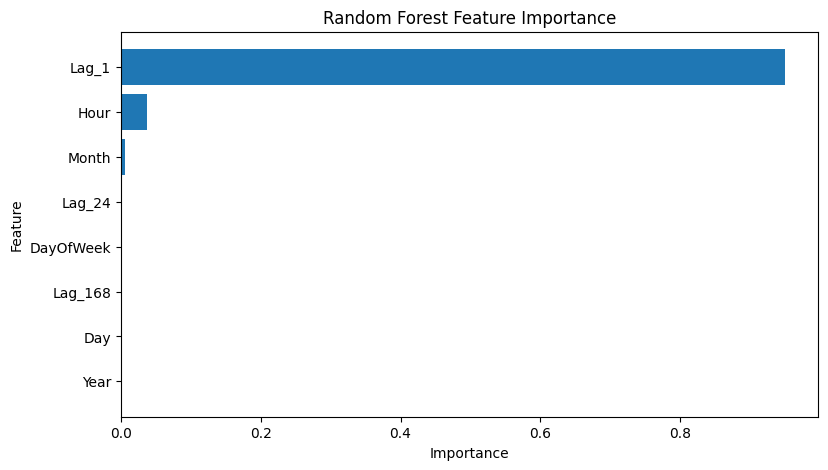

In [153]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

## Feature Importance Analysis

Lag_1 is the most important feature in the Random Forest model,
with an importance of approximately 95.03%.

Hour is the second most important feature, with an importance
of approximately 3.80%.

The remaining features have relatively small individual
importance values.

This indicates that recent hourly demand is the strongest
predictor of the current power demand in the Random Forest model.

## Saving Final Model Results

The final model performance results and the 30-day SARIMA
forecast are saved as CSV files for reporting and deployment.

In [157]:
# Create final model comparison table

final_model_comparison = pd.DataFrame({
    "Model": ["SARIMA", "Random Forest"],
    "MAE": [final_mae, rf_final_mae],
    "RMSE": [final_rmse, rf_final_rmse],
    "MAPE (%)": [final_mape, rf_final_mape]
})

# Save final model comparison
final_model_comparison.to_csv(
    "../reports/final_model_comparison.csv",
    index=False
)

final_model_comparison

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,2096.070552,2469.086490,35.585344
1,Random Forest,60.534025,79.901623,1.057752


In [159]:
# Save 30-day SARIMA forecast

sarima_30day_forecast.to_csv(
    "../reports/sarima_30_day_forecast.csv"
)

print("Final model results saved successfully.")
print("30-day SARIMA forecast saved successfully.")

Final model results saved successfully.
30-day SARIMA forecast saved successfully.
